# Multilingual Tokenization Case Study

This notebook investigates how tokenization choices affect multilingual NLP under a low-resource setup.

**Research question:** Which tokenization strategy offers the best trade-off between token coverage and downstream performance across typologically different languages?

**Languages:** English, Turkish, Swahili, Amharic  
**Task:** intent classification on MASSIVE  
**Training regime:** 3,000 examples per language to simulate a constrained-resource setting  
**Tokenizers compared:** word-level baseline, SentencePiece BPE, SentencePiece unigram

## Project Plan

1. Select a multilingual benchmark with aligned labels across several languages.
2. Create a low-resource subset to stress token coverage and generalization.
3. Train three tokenization strategies per language.
4. Measure intrinsic properties:
   - OOV piece rate
   - word coverage
   - fertility (pieces per whitespace word)
   - characters per token
5. Measure downstream performance with the same TF-IDF + Linear SVM intent classifier for every tokenizer.
6. Summarize the findings.

## Notebook Setup

This first code block imports the libraries and defines the constants used throughout the notebook. The main design choice here is to keep the language set and tokenizer budget fixed so later comparisons are easier to trust.

In [1]:
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import tempfile

import pandas as pd
import sentencepiece as spm
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# I keep the language set intentionally compact so the notebook stays readable
# while still comparing different morphology patterns and scripts.
LANGUAGES = {
    "en": "English",
    "tr": "Turkish",
    "sw": "Swahili",
    "am": "Amharic",
}
RANDOM_STATE = 42
LOW_RESOURCE_TRAIN_SIZE = 3000
TOKENIZER_VOCAB_SIZE = 800
WORD_VOCAB_SIZE = 800

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "outputs" / "data"
FIGURE_DIR = ROOT / "outputs" / "figures"
TOKENIZER_DIR = ROOT / "outputs" / "tokenizers"

TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)

## Helper Functions

Before touching the data, I define a few small utilities: one baseline tokenizer, one wrapper around SentencePiece, a low-resource sampler, and a shared evaluation function. Grouping them here keeps the actual experiment loop cleaner.

In [2]:
@dataclass
class WordLevelTokenizer:
    vocab: set[str]
    unk_token: str = "<unk>"

    def encode(self, text: str) -> list[str]:
        # This is the strict baseline: unseen words immediately become <unk>.
        return [token if token in self.vocab else self.unk_token for token in text.split()]


@dataclass
class SentencePieceTokenizer:
    processor: spm.SentencePieceProcessor

    def encode(self, text: str) -> list[str]:
        return self.processor.encode(text, out_type=str)


def sample_low_resource_split(frame: pd.DataFrame, size: int) -> pd.DataFrame:
    # Stratifying here keeps the intent distribution roughly stable.
    sampled, _ = train_test_split(
        frame,
        train_size=size,
        random_state=RANDOM_STATE,
        stratify=frame["label"],
    )
    return sampled.reset_index(drop=True)


def build_word_tokenizer(texts, vocab_size: int) -> WordLevelTokenizer:
    counts = Counter()
    for text in texts:
        counts.update(text.split())

    # The word-level tokenizer is just a shortlist of the most common tokens.
    return WordLevelTokenizer(vocab={token for token, _ in counts.most_common(vocab_size - 1)})


def build_sentencepiece_tokenizer(texts, language_code: str, model_type: str, vocab_size: int):
    model_prefix = TOKENIZER_DIR / f"{language_code}_{model_type}"
    # SentencePiece wants a raw text file, so I build one on the fly.
    with tempfile.NamedTemporaryFile("w", encoding="utf-8", delete=False, suffix=".txt") as handle:
        for text in texts:
            handle.write(text.replace("\n", " ").strip() + "\n")
        corpus_path = Path(handle.name)

    spm.SentencePieceTrainer.train(
        input=str(corpus_path),
        model_prefix=str(model_prefix),
        model_type=model_type,
        vocab_size=vocab_size,
        character_coverage=1.0,
        bos_id=-1,
        eos_id=-1,
        pad_id=0,
        unk_id=1,
    )
    corpus_path.unlink(missing_ok=True)
    processor = spm.SentencePieceProcessor(model_file=str(model_prefix) + ".model")
    return SentencePieceTokenizer(processor=processor)


def evaluate_classifier(tokenizer, train_df: pd.DataFrame, test_df: pd.DataFrame):
    # Every tokenizer is evaluated with the same classifier so the tokenizer is
    # the main thing changing between runs.
    train_texts = [" ".join(tokenizer.encode(text)) for text in train_df["text"]]
    test_texts = [" ".join(tokenizer.encode(text)) for text in test_df["text"]]

    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_features=20000,
    )

    x_train = vectorizer.fit_transform(train_texts)
    x_test = vectorizer.transform(test_texts)

    classifier = LinearSVC(random_state=RANDOM_STATE)
    classifier.fit(x_train, train_df["label"])
    predictions = classifier.predict(x_test)

    return {
        "macro_f1": f1_score(test_df["label"], predictions, average="macro"),
        "accuracy": accuracy_score(test_df["label"], predictions),
    }

## Loading the Benchmark

At this stage I pull the MASSIVE data for each language into Pandas data frames. I keep only the text and label columns because that is all this case study needs for tokenization analysis and intent classification.

In [3]:
language_frames = {}
for code in LANGUAGES:
    # Each language is loaded separately, but all of them share the same label space.
    dataset = load_dataset("mteb/MassiveIntentClassification", code)
    language_frames[code] = {
        split: pd.DataFrame(dataset[split])[["text", "label"]]
        for split in ("train", "validation", "test")
    }

# This quick check makes sure the data loaded correctly before training anything heavier.
{code: {split: len(frame) for split, frame in splits.items()} for code, splits in language_frames.items()}

{'en': {'train': 11514, 'validation': 2033, 'test': 2974},
 'tr': {'train': 11514, 'validation': 2033, 'test': 2974},
 'sw': {'train': 11514, 'validation': 2033, 'test': 2974},
 'am': {'train': 11514, 'validation': 2033, 'test': 2974}}

## Running the Comparison

This is the core experiment loop. For each language, I create a low-resource training subset, train three tokenizer variants under the same vocabulary budget, and then evaluate them with the same downstream classifier.

In [4]:
experiment_rows = []

for code, language_name in LANGUAGES.items():
    # I downsample only the training split so the comparison behaves like a
    # low-resource setup but the test evaluation stays stable.
    train_df = sample_low_resource_split(language_frames[code]["train"], LOW_RESOURCE_TRAIN_SIZE)
    test_df = language_frames[code]["test"].reset_index(drop=True)

    # All tokenizers get the same vocabulary budget to keep the comparison fair.
    tokenizers = {
        "word": build_word_tokenizer(train_df["text"], WORD_VOCAB_SIZE),
        "bpe": build_sentencepiece_tokenizer(train_df["text"], code, "bpe", TOKENIZER_VOCAB_SIZE),
        "unigram": build_sentencepiece_tokenizer(train_df["text"], code, "unigram", TOKENIZER_VOCAB_SIZE),
    }

    for tokenizer_name, tokenizer in tokenizers.items():
        scores = evaluate_classifier(tokenizer, train_df, test_df)
        experiment_rows.append(
            {
                "language": language_name,
                "tokenizer": tokenizer_name,
                **scores,
            }
        )

pd.DataFrame(experiment_rows).sort_values(["language", "macro_f1"], ascending=[True, False])

,language,tokenizer,macro_f1,accuracy
10,Amharic,bpe,0.643359,0.710155
11,Amharic,unigram,0.632844,0.700067
9,Amharic,word,0.567278,0.641560
2,English,unigram,0.711755,0.765636
1,English,bpe,0.703632,0.767653
0,English,word,0.683026,0.756893
8,Swahili,unigram,0.708673,0.746133
7,Swahili,bpe,0.697109,0.738736
6,Swahili,word,0.672455,0.715871
4,Turkish,bpe,0.694505,0.748823


## Reading the Saved Results

The experiment script writes its outputs to CSV so the analysis stays reproducible. Here I reload those files instead of recomputing everything, which keeps the notebook faster and easier to inspect.

In [5]:
import pandas as pd

# From this point on, I switch from running the experiment to reading the
# exported result tables that were saved by the pipeline script.
summary_df = pd.read_csv(DATA_DIR / "summary_metrics.csv")
intrinsic_df = pd.read_csv(DATA_DIR / "intrinsic_metrics.csv")
downstream_df = pd.read_csv(DATA_DIR / "downstream_metrics.csv")

summary_df

,language,best_tokenizer,best_macro_f1,word_macro_f1,bpe_macro_f1,unigram_macro_f1
0,Amharic,bpe,0.643359,0.567278,0.643359,0.632844
1,English,unigram,0.711755,0.683026,0.703632,0.711755
2,Swahili,unigram,0.708673,0.672455,0.697109,0.708673
3,Turkish,bpe,0.694505,0.596519,0.694505,0.666774


## Main Findings

| language | best_tokenizer | best_macro_f1 | word_to_best_gain |
| --- | --- | --- | --- |
| Amharic | bpe | 0.643 | 0.076 |
| English | unigram | 0.712 | 0.029 |
| Swahili | unigram | 0.709 | 0.037 |
| Turkish | bpe | 0.695 | 0.098 |

## Intrinsic Metrics

| language | tokenizer | oov_piece_rate | avg_fertility | avg_chars_per_token | avg_word_coverage |
| --- | --- | --- | --- | --- | --- |
| Amharic | bpe | 0.000 | 2.190 | 2.129 | 1.000 |
| Amharic | unigram | 0.000 | 2.275 | 2.060 | 1.000 |
| Amharic | word | 0.328 | 1.000 | 4.333 | 0.664 |
| English | bpe | 0.000 | 1.536 | 3.590 | 1.000 |
| English | unigram | 0.000 | 1.529 | 3.672 | 1.000 |
| English | word | 0.141 | 1.000 | 5.160 | 0.850 |
| Swahili | bpe | 0.000 | 1.636 | 3.958 | 1.000 |
| Swahili | unigram | 0.000 | 1.740 | 3.770 | 1.000 |
| Swahili | word | 0.174 | 1.000 | 6.009 | 0.813 |
| Turkish | bpe | 0.000 | 2.034 | 3.422 | 1.000 |
| Turkish | unigram | 0.000 | 1.965 | 3.635 | 1.000 |
| Turkish | word | 0.308 | 1.000 | 6.435 | 0.686 |

## Downstream Metrics

| tokenizer | macro_f1 | accuracy | language |
| --- | --- | --- | --- |
| bpe | 0.643 | 0.710 | Amharic |
| unigram | 0.633 | 0.700 | Amharic |
| word | 0.567 | 0.642 | Amharic |
| bpe | 0.704 | 0.768 | English |
| unigram | 0.712 | 0.766 | English |
| word | 0.683 | 0.757 | English |
| bpe | 0.697 | 0.739 | Swahili |
| unigram | 0.709 | 0.746 | Swahili |
| word | 0.672 | 0.716 | Swahili |
| bpe | 0.695 | 0.749 | Turkish |
| unigram | 0.667 | 0.739 | Turkish |
| word | 0.597 | 0.660 | Turkish |

## Visual Comparison

The tables above are the exact numbers, but plots make the pattern easier to read quickly. In particular, I want to see whether the same tokenizers that improve coverage also tend to improve downstream macro-F1.

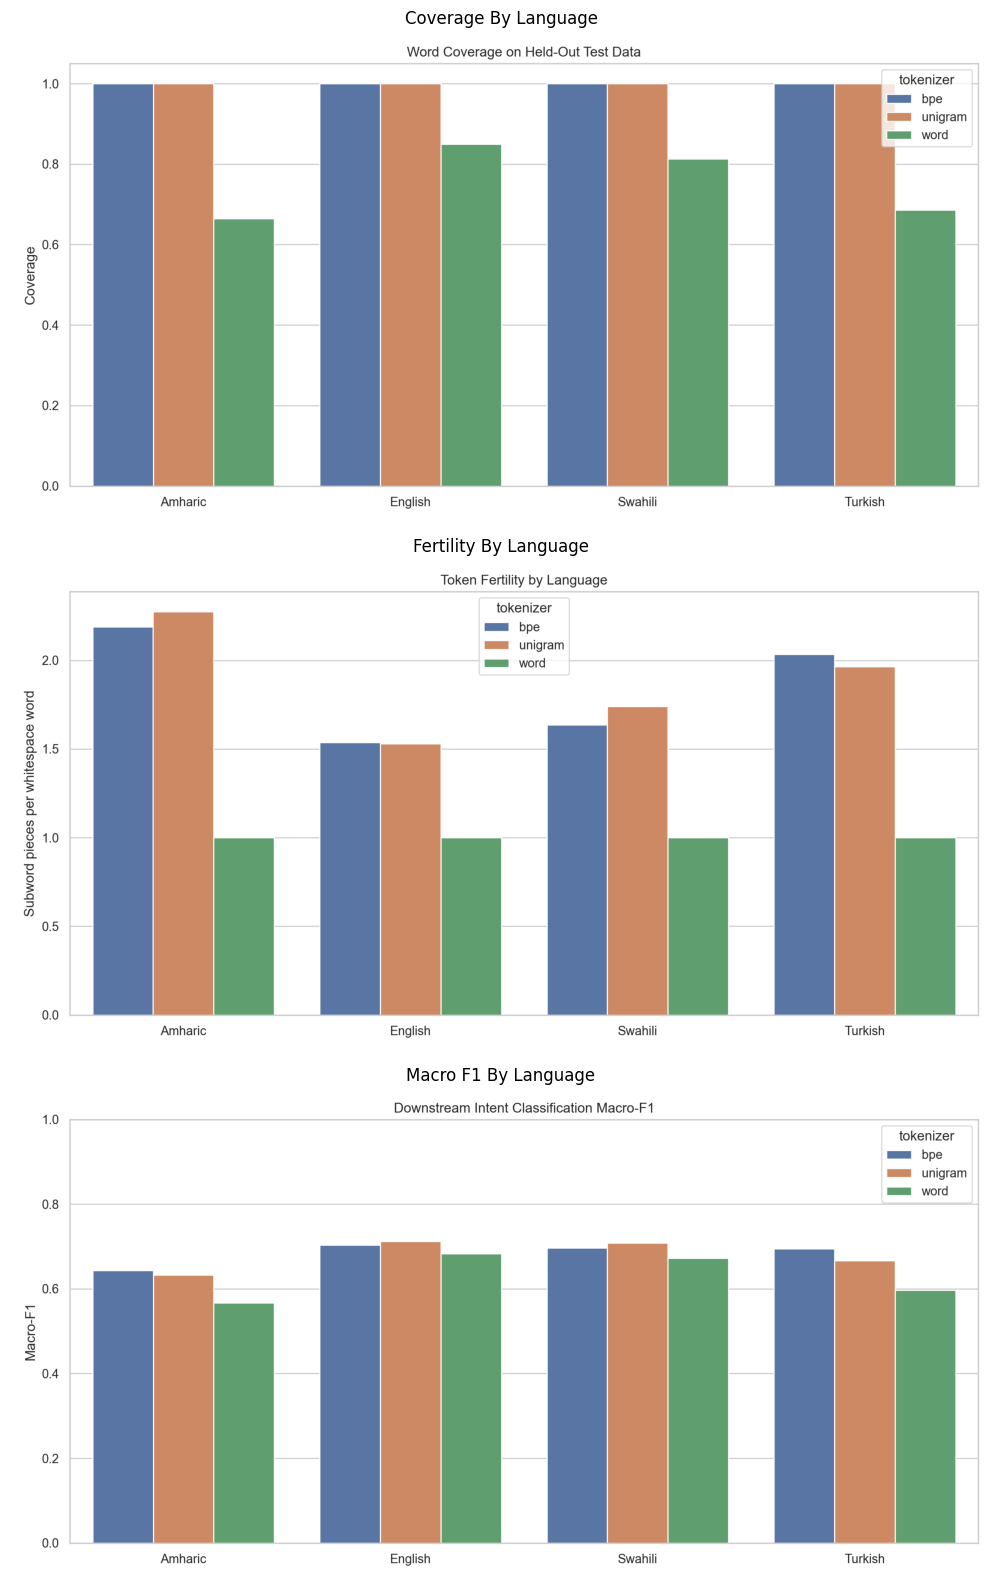

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

figure_paths = [
    FIGURE_DIR / "coverage_by_language.png",
    FIGURE_DIR / "fertility_by_language.png",
    FIGURE_DIR / "macro_f1_by_language.png",
]

# These plots are already saved by the main pipeline, so here I just display
# them together in one place for easier reading inside the notebook.
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
for axis, path in zip(axes, figure_paths):
    axis.imshow(mpimg.imread(path))
    axis.set_title(path.stem.replace("_", " ").title())
    axis.axis("off")
plt.tight_layout()

## Interpretation

- Word-level tokenization suffered the most in Turkish and Amharic, where the OOV piece rate reached **0.308** and **0.328** respectively.
- Both subword approaches achieved **1.000 word coverage** on the held-out set in all four languages.
- The best downstream tokenizer was language-dependent: unigram led on English and Swahili, while BPE led on Turkish and Amharic.
- The largest downstream gain over the word baseline appeared in Turkish, where the best subword tokenizer improved macro-F1 by **0.098**.

## Reproduction

The full pipeline lives in `run_case_study.py`. Re-run the experiments from the repository root:

```bash
python run_case_study.py
```

The command regenerates the metrics and figures.